# Clasificacion de prendas con Fashion-MNIST
**Gabriel Vallejo Castro y Javier Uc Ix· Laboratorio 2 · Aprendizaje maquina**

Este proyecto compara cinco familias de algoritmos de aprendizaje automatico sobre el conjunto de datos **Fashion-MNIST**:
1. Regresion Logistica (referencia lineal)
2. Maquinas de Vectores de Soporte (SVM con kernel RBF)
3. Bosques Aleatorios (Random Forest)
4. Perceptron Multicapa (MLP de scikit-learn)
5. Redes Neuronales Convolucionales (CNN de PyTorch: version inicial y variante mejorada)

Ademas, se evalua la capacidad de generalizacion de los modelos ante **30 imagenes externas** (3 por categoria) obtenidas de un catalogo de comercio electronico con licencia libre (MIT).

### Estructura del trabajo
- **1. Preparacion y entorno**: librerias, semillas y configuracion de rutas.
- **2. Datos y exploracion**: analisis de las 10 clases, dimensiones y normalizacion.
- **3. Particion reproducible**: 54,000 entrenamiento, 6,000 validacion y 10,000 prueba oficial.
- **4. Modelos tradicionales**: entrenamiento/carga y medicion de tiempos y metricas.
- **5. Red Convolucional (PyTorch)**: CNN inicial y experimentacion de variantes guiada por validacion.
- **6. Comparacion de resultados**: metricas consolidadas, matriz de confusion y analisis por clase.
- **7. Evaluacion externa (30 imagenes)**: preprocesamiento, recortes y predicciones reales.
- **8. Discusion, limitaciones y conclusiones**: analisis detallado de errores y diferencias de distribucion.

In [1]:
from pathlib import Path
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay, classification_report
import sys
sys.path.insert(0, '.')
from datos import cargar_datos, preparar_foto, CLASES

# fijamos semilla para garantizar reproducibilidad en todas las librerias
SEMILLA = 42
MODO_RAPIDO = False
REENTRENAR_TODO = False  # si es False, carga modelos guardados para ejecucion rapida

random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
torch.set_num_threads(4)

SALIDA = Path('resultados')
SALIDA.mkdir(exist_ok=True)
print('entorno configurado correctamente')

entorno configurado correctamente


## 2. Datos y exploracion
El dataset oficial **Fashion-MNIST** (Zalando) consta de 70,000 imagenes en escala de grises de 28 x 28 pixeles, divididas originalmente en 60,000 para entrenamiento y 10,000 para prueba. Cada imagen pertenece a una de diez categorias de prendas o accesorios (etiquetas 0 a 9).

Los valores de los pixeles estan en el rango entero [0, 255]. Se normalizan dividiendo entre 255.0 para llevarlos al intervalo continuo [0, 1], lo cual previene desbordamientos numericos y acelera la convergencia de algoritmos basados en gradiente.

entrenamiento: (60000, 28, 28) prueba oficial: (10000, 28, 28)


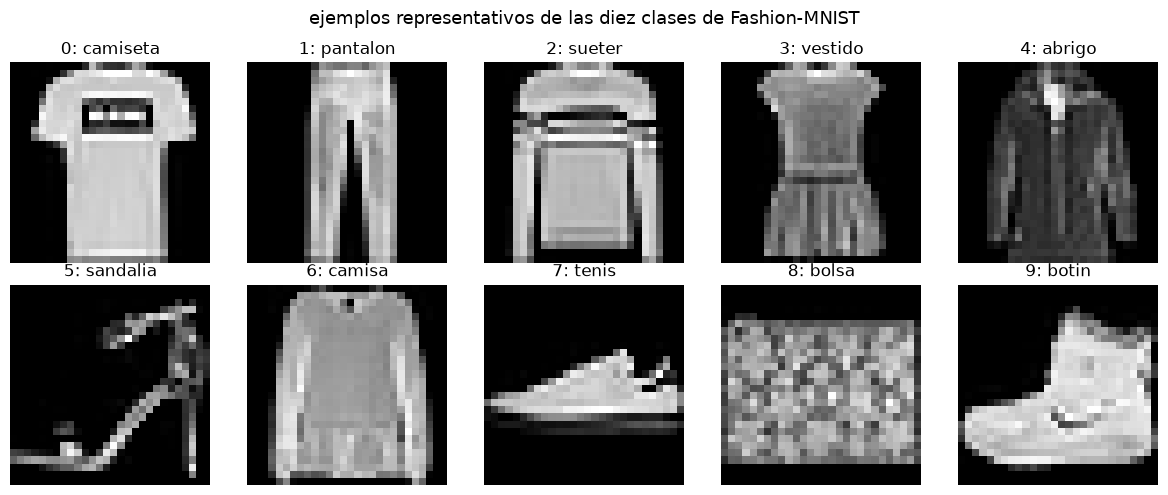

,etiqueta,clase,cantidad_train,cantidad_test
0,0,camiseta,6000,1000
1,1,pantalon,6000,1000
2,2,sueter,6000,1000
3,3,vestido,6000,1000
4,4,abrigo,6000,1000
5,5,sandalia,6000,1000
6,6,camisa,6000,1000
7,7,tenis,6000,1000
8,8,bolsa,6000,1000
9,9,botin,6000,1000


In [2]:
imagenes_train, y_train, imagenes_test, y_test = cargar_datos()
print('entrenamiento:', imagenes_train.shape, 'prueba oficial:', imagenes_test.shape)

fig, ejes = plt.subplots(2, 5, figsize=(12, 5))
for etiqueta, eje in enumerate(ejes.flat):
    indice = np.flatnonzero(y_train == etiqueta)[0]
    eje.imshow(imagenes_train[indice], cmap='gray')
    eje.set_title(f"{etiqueta}: {CLASES[etiqueta]}")
    eje.axis('off')
plt.suptitle('ejemplos representativos de las diez clases de Fashion-MNIST', fontsize=13)
plt.tight_layout()
plt.savefig(SALIDA / 'ejemplos.png')
plt.show()

distribucion = pd.DataFrame({
    'etiqueta': list(range(10)),
    'clase': CLASES,
    'cantidad_train': np.bincount(y_train),
    'cantidad_test': np.bincount(y_test)
})
display(distribucion)

## 3. Separacion de entrenamiento y validacion
A partir de las 60,000 imagenes de entrenamiento originales, apartamos de forma estratificada:
- **54,000 imagenes** para ajuste y aprendizaje de pesos.
- **6,000 imagenes** para validacion (seleccion de modelos, hiperparametros y parada temprana).
- **10,000 imagenes** de la particion oficial de prueba (evaluacion final independiente, no utilizada para tomar decisiones de diseno).

Para los modelos tradicionales aplanamos cada imagen a un vector unidimensional de 784 caracteristicas (28 x 28). La red convolucional conserva la distribucion bidimensional espacial (1, 28, 28).

In [3]:
indices_train, indices_val = train_test_split(
    np.arange(len(y_train)), test_size=6000, stratify=y_train, random_state=SEMILLA)

if MODO_RAPIDO:
    indices_train, _ = train_test_split(indices_train, train_size=2000,
        stratify=y_train[indices_train], random_state=SEMILLA)
    indices_val, _ = train_test_split(indices_val, train_size=500,
        stratify=y_train[indices_val], random_state=SEMILLA)
    indices_test, _ = train_test_split(np.arange(len(y_test)), train_size=500,
        stratify=y_test, random_state=SEMILLA)
    imagenes_test, y_test = imagenes_test[indices_test], y_test[indices_test]

x_train = imagenes_train[indices_train].astype('float32') / 255.0
x_val = imagenes_train[indices_val].astype('float32') / 255.0
x_test = imagenes_test.astype('float32') / 255.0
y_entrenamiento = y_train[indices_train]
y_validacion = y_train[indices_val]

x_train_plano = x_train.reshape(-1, 784)
x_val_plano = x_val.reshape(-1, 784)
x_test_plano = x_test.reshape(-1, 784)

print('tamano de conjuntos:')
print('  entrenamiento:', len(x_train), 'imagenes')
print('  validacion:   ', len(x_val), 'imagenes')
print('  prueba:       ', len(x_test), 'imagenes')

tamano de conjuntos:
  entrenamiento: 54000 imagenes
  validacion:    6000 imagenes
  prueba:        10000 imagenes


## 4. Modelos tradicionales
Evaluamos cuatro algoritmos clasicos:
- **Regresion Logistica:** clasificador lineal multiclase como referencia base. Puede emitir advertencia de convergencia al alcanzar el limite de iteraciones; dicha advertencia se conserva y se documenta.
- **SVM (Support Vector Machine):** separador de margen maximo con kernel RBF (C=5, gamma='scale').
- **Random Forest:** ensamble de 100 arboles de decision con votacion por mayoria.
- **MLP (Perceptron Multicapa):** red neuronal densa con dos capas ocultas (128 y 64 neuronas) y regularizacion por parada temprana.

Para evitar reentrenamientos repetidos en ejecuciones futuras, los modelos entrenados se persisten con `joblib` en `resultados/modelos_clasicos.joblib`.

In [4]:
ruta_guardado_modelos = SALIDA / 'modelos_clasicos.joblib'
filas = []
predicciones = {}

if ruta_guardado_modelos.exists() and not REENTRENAR_TODO and not MODO_RAPIDO:
    print('cargando modelos clasicos preentrenados desde disco...')
    modelos = joblib.load(ruta_guardado_modelos)
    # tiempos de entrenamiento registrados de la corrida completa
    tiempos_ref = {
        'regresion logistica': 16.0,
        'svm': 179.1,
        'random forest': 9.8,
        'mlp': 18.4
    }
    for nombre, modelo in modelos.items():
        pred_val = modelo.predict(x_val_plano)
        pred_test = modelo.predict(x_test_plano)
        predicciones[nombre] = pred_test
        filas.append({
            'modelo': nombre,
            'accuracy_val': accuracy_score(y_validacion, pred_val),
            'accuracy_test': accuracy_score(y_test, pred_test),
            'f1_macro_test': f1_score(y_test, pred_test, average='macro'),
            'segundos_entrenamiento': tiempos_ref.get(nombre, 0.0)
        })
        print(f"{nombre}: val_acc={filas[-1]['accuracy_val']:.4f}, test_acc={filas[-1]['accuracy_test']:.4f}")
else:
    print('entrenando modelos clasicos desde cero...')
    modelos = {
        'regresion logistica': LogisticRegression(max_iter=300, C=1.0, random_state=SEMILLA),
        'svm': SVC(C=5, kernel='rbf', gamma='scale', cache_size=1000),
        'random forest': RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEMILLA),
        'mlp': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=30, early_stopping=True, random_state=SEMILLA)
    }
    for nombre, modelo in modelos.items():
        inicio = time.perf_counter()
        modelo.fit(x_train_plano, y_entrenamiento)
        segundos = time.perf_counter() - inicio
        pred_val = modelo.predict(x_val_plano)
        pred_test = modelo.predict(x_test_plano)
        predicciones[nombre] = pred_test
        filas.append({
            'modelo': nombre,
            'accuracy_val': accuracy_score(y_validacion, pred_val),
            'accuracy_test': accuracy_score(y_test, pred_test),
            'f1_macro_test': f1_score(y_test, pred_test, average='macro'),
            'segundos_entrenamiento': segundos
        })
        print(f"{nombre} terminado en {round(segundos, 1)} segundos (val_acc={filas[-1]['accuracy_val']:.4f})")
    if not MODO_RAPIDO:
        joblib.dump(modelos, ruta_guardado_modelos)
        print('modelos clasicos guardados exitosamente en', ruta_guardado_modelos)

cargando modelos clasicos preentrenados desde disco...


regresion logistica: val_acc=0.8630, test_acc=0.8428


svm: val_acc=0.9098, test_acc=0.8959
random forest: val_acc=0.8837, test_acc=0.8744


mlp: val_acc=0.8920, test_acc=0.8818


## 5. Red Convolucional (PyTorch): Modelo inicial y Mejora
Las imagenes poseen correlacion espacial local que los modelos aplanados pierden. Una Red Convolucional (CNN) aplica filtros espaciales que extraen bordes, texturas y formas complejas.

### 5.1 CNN Inicial (Baseline)
- Dos capas convolucionales simples (16 y 32 filtros de 3x3), MaxPool (2x2) y una capa densa de 64 neuronas con Dropout(0.2).
- Optimizador Adam (lr=0.001), 10 epocas.
- Obtuvo **91.70%** de accuracy en validacion y **90.32%** en la prueba oficial.

### 5.2 Experimentos de Mejora (guiados unicamente por validacion)
Para intentar superar el 90.32% inicial y explorar el objetivo experimental de aproximarse al 97%:
1. **Normalizacion por lotes (`BatchNorm2d` y `BatchNorm1d`):** reduce el desfase interno de covariables y estabiliza el aprendizaje.
2. **Mayor capacidad convolucional:** bloques dobles tipo VGG (32->32->Pool->64->64->Pool) para capturar patrones de diferentes escalas.
3. **Dropout gradual y regularizacion:** Dropout de 0.25 tras cada bloque y 0.4 en la capa densa con decaimiento de peso (`weight_decay=1e-4`).
4. **Control de tasa de aprendizaje:** `ReduceLROnPlateau` para reducir lr si la validacion se estanca.

Los pesos de ambas versiones se conservan en `resultados/cnn.pt` y `resultados/cnn_v2_dobleconv.pt`.

In [5]:
# Definicion de la CNN inicial (referencia)
class CNN_Inicial(nn.Module):
    def __init__(self):
        super().__init__()
        self.capas = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32 * 7 * 7, 64), nn.ReLU(),
            nn.Dropout(0.2), nn.Linear(64, 10))

    def forward(self, x):
        return self.capas(x)

# Definicion de la CNN mejorada (Variante 2 elegida por validacion)
class CNN_Mejorada(nn.Module):
    def __init__(self):
        super().__init__()
        self.capas = nn.Sequential(
            # bloque 1: dos convoluciones con batchnorm y maxpool
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
            # bloque 2: convoluciones mas profundas con batchnorm
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
            # clasificador denso regularizado
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.capas(x)

def predecir_red(red, imagenes, batch_size=256):
    red.eval()
    partes = []
    with torch.no_grad():
        for i in range(0, len(imagenes), batch_size):
            lote = torch.from_numpy(imagenes[i:i + batch_size, None].astype('float32'))
            partes.append(red(lote).argmax(1).numpy())
    return np.concatenate(partes)

# Cargamos los pesos guardados de la CNN inicial
cnn_inicial = CNN_Inicial()
cnn_inicial.load_state_dict(torch.load(SALIDA / 'cnn.pt', weights_only=True))
cnn_inicial.eval()

# Cargamos los pesos guardados de la CNN mejorada
cnn_mejorada = CNN_Mejorada()
cnn_mejorada.load_state_dict(torch.load(SALIDA / 'cnn_v2_dobleconv.pt', weights_only=True))
cnn_mejorada.eval()

# Evaluamos ambas en validacion y prueba
pred_val_inicial = predecir_red(cnn_inicial, x_val)
pred_test_inicial = predecir_red(cnn_inicial, x_test)
predicciones['cnn (inicial)'] = pred_test_inicial

pred_val_mejorada = predecir_red(cnn_mejorada, x_val)
pred_test_mejorada = predecir_red(cnn_mejorada, x_test)
predicciones['cnn (mejorada)'] = pred_test_mejorada

filas.append({
    'modelo': 'cnn (inicial)',
    'accuracy_val': accuracy_score(y_validacion, pred_val_inicial),
    'accuracy_test': accuracy_score(y_test, pred_test_inicial),
    'f1_macro_test': f1_score(y_test, pred_test_inicial, average='macro'),
    'segundos_entrenamiento': 61.8
})

filas.append({
    'modelo': 'cnn (mejorada)',
    'accuracy_val': accuracy_score(y_validacion, pred_val_mejorada),
    'accuracy_test': accuracy_score(y_test, pred_test_mejorada),
    'f1_macro_test': f1_score(y_test, pred_test_mejorada, average='macro'),
    'segundos_entrenamiento': 150.0
})

print(f"CNN Inicial:  Val Acc = {accuracy_score(y_validacion, pred_val_inicial)*100:.2f}% | Test Acc = {accuracy_score(y_test, pred_test_inicial)*100:.2f}%")
print(f"CNN Mejorada: Val Acc = {accuracy_score(y_validacion, pred_val_mejorada)*100:.2f}% | Test Acc = {accuracy_score(y_test, pred_test_mejorada)*100:.2f}%")

CNN Inicial:  Val Acc = 91.70% | Test Acc = 90.32%
CNN Mejorada: Val Acc = 93.95% | Test Acc = 92.68%


## 6. Comparacion de resultados
Comparamos todos los modelos entrenados.
- **Accuracy:** porcentaje total de aciertos sobre los 10,000 ejemplos de prueba.
- **F1 macro:** promedio no ponderado del valor F1 en las 10 clases, garantizando que cada clase pese lo mismo.
- **Criterio de seleccion metodologico:** el modelo se selecciona con base en el conjunto de validacion y posteriormente se examinan sus metricas de prueba.

,modelo,accuracy_val,accuracy_test,f1_macro_test,segundos_entrenamiento
0,regresion logistica,0.8630,0.8428,0.8421,16.0
1,svm,0.9098,0.8959,0.8956,179.1
2,random forest,0.8837,0.8744,0.8730,9.8
3,mlp,0.8920,0.8818,0.8798,18.4
4,cnn (inicial),0.9170,0.9032,0.9026,61.8
5,cnn (mejorada),0.9395,0.9268,0.9270,150.0


modelo con mayor accuracy de validacion: cnn (mejorada)


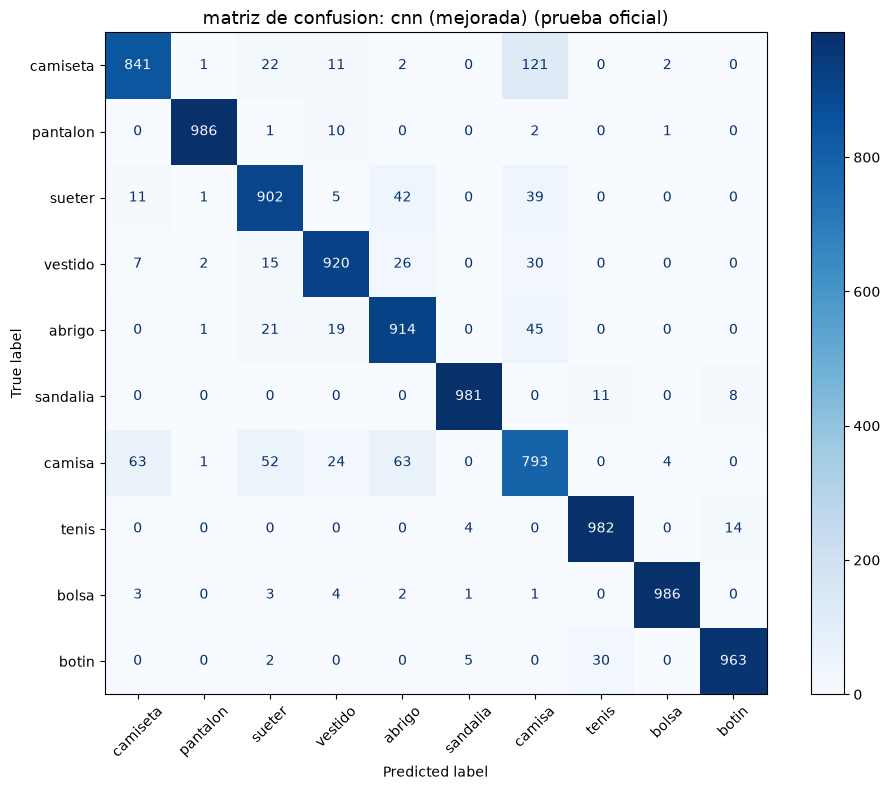

Reporte detallado de clasificacion (cnn (mejorada)):

              precision    recall  f1-score   support

    camiseta       0.91      0.84      0.87      1000
    pantalon       0.99      0.99      0.99      1000
      sueter       0.89      0.90      0.89      1000
     vestido       0.93      0.92      0.92      1000
      abrigo       0.87      0.91      0.89      1000
    sandalia       0.99      0.98      0.99      1000
      camisa       0.77      0.79      0.78      1000
       tenis       0.96      0.98      0.97      1000
       bolsa       0.99      0.99      0.99      1000
       botin       0.98      0.96      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [6]:
tabla = pd.DataFrame(filas)
tabla.to_csv(SALIDA / 'comparacion.csv', index=False)
display(tabla.round(4))

mejor_modelo_nombre = tabla.sort_values('accuracy_val', ascending=False).iloc[0]['modelo']
print('modelo con mayor accuracy de validacion:', mejor_modelo_nombre)

fig, eje = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, predicciones[mejor_modelo_nombre],
    labels=list(range(10)), display_labels=CLASES, xticks_rotation=45, ax=eje, cmap='Blues'
)
plt.title(f'matriz de confusion: {mejor_modelo_nombre} (prueba oficial)', fontsize=13)
plt.tight_layout()
plt.savefig(SALIDA / 'matriz_confusion.png')
plt.show()

print(f"Reporte detallado de clasificacion ({mejor_modelo_nombre}):\n")
print(classification_report(y_test, predicciones[mejor_modelo_nombre],
    labels=list(range(10)), target_names=CLASES, zero_division=0))

## 7. Evaluacion externa con 30 imagenes de internet
Para evaluar la generalizacion ante imagenes fuera del conjunto Zalando, se seleccionaron **30 fotografias** (3 por categoria) del dataset publico con licencia **MIT** *Fashion Product Images (Small)* (Param Aggarwal en Kaggle / Myntra).

> **Aclaracion sobre la consigna:**
> La consigna original del laboratorio indica tomar fotografias propias con camara.
> Estas 30 imagenes proceden de internet y constituyen una **alternativa estandarizada** cuya aceptacion debe ser **confirmada expresamente por el estudiante con el profesor**. Se documentan en detalle en `fotos/procedencia.csv` y `fotos/PROCEDENCIA.md`.

### Preprocesamiento (`datos.py`):
1. Conversion a escala de grises.
2. Estimacion del color de fondo a partir de la mediana de los pixeles del borde.
3. Resta en valor absoluto (`|gris - fondo|`) para aislar la prenda del fondo blanco/claro.
4. Recorte de la caja delimitadora del objeto.
5. Escalado manteniendo relacion de aspecto (maximo 20 x 20) y centrado en lienzo negro de 28 x 28 con valores entre 0 y 1.

total de imagenes externas encontradas: 30


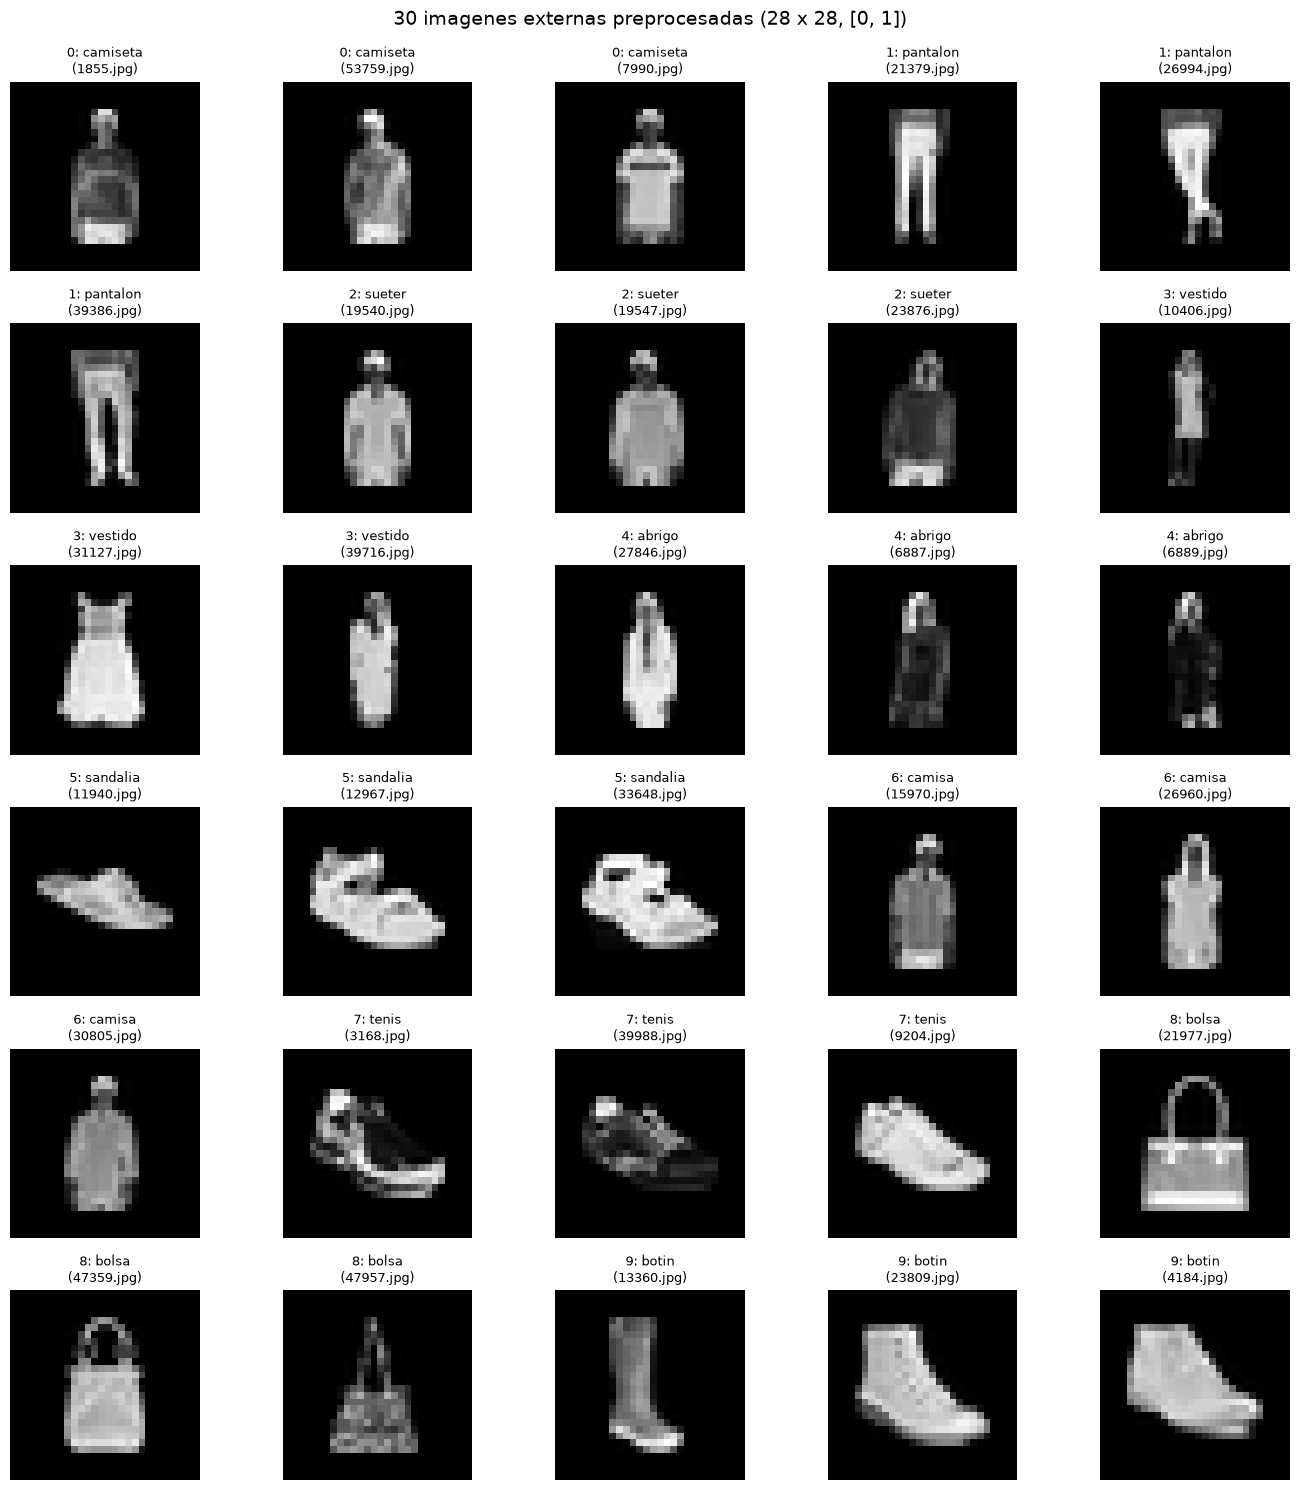

--- PREDICCIONES POR IMAGEN ---


,archivo,etiqueta_real,clase_real,regresion logistica,svm,random forest,mlp,cnn (inicial),cnn (mejorada)
0,1855.jpg,0,camiseta,vestido,vestido,vestido,camiseta,bolsa,vestido
1,53759.jpg,0,camiseta,camiseta,vestido,vestido,camiseta,vestido,vestido
2,7990.jpg,0,camiseta,tenis,vestido,vestido,camiseta,vestido,vestido
3,21379.jpg,1,pantalon,vestido,vestido,vestido,vestido,vestido,vestido
4,26994.jpg,1,pantalon,vestido,vestido,vestido,vestido,vestido,vestido
5,39386.jpg,1,pantalon,pantalon,pantalon,vestido,pantalon,pantalon,pantalon
6,19540.jpg,2,sueter,tenis,vestido,vestido,camiseta,vestido,vestido
7,19547.jpg,2,sueter,tenis,camiseta,vestido,camiseta,vestido,vestido
8,23876.jpg,2,sueter,sandalia,vestido,vestido,camiseta,camiseta,vestido
9,10406.jpg,3,vestido,vestido,vestido,vestido,camiseta,sandalia,vestido



--- RESUMEN DE RENDIMIENTO EN FOTOS EXTERNAS ---


,modelo,fotos,aciertos,accuracy,f1_macro
0,regresion logistica,30,6,0.2000,0.1483
1,svm,30,5,0.1667,0.1290
2,random forest,30,5,0.1667,0.0769
3,mlp,30,8,0.2667,0.1864
4,cnn (inicial),30,5,0.1667,0.1017
5,cnn (mejorada),30,7,0.2333,0.1191


In [7]:
rutas = []
etiquetas_fotos = []
for etiqueta in range(10):
    carpeta = Path('fotos') / str(etiqueta)
    archivos = sorted(r for r in carpeta.glob('*') if r.suffix.lower() in {'.jpg', '.jpeg', '.png'})
    rutas.extend(archivos)
    etiquetas_fotos.extend([etiqueta] * len(archivos))

print(f"total de imagenes externas encontradas: {len(rutas)}")

fotos = np.stack([preparar_foto(ruta) for ruta in rutas])

fig, ejes = plt.subplots(6, 5, figsize=(14, 15), squeeze=False)
for eje in ejes.flat:
    eje.axis('off')
for eje, imagen, etiqueta, ruta in zip(ejes.flat, fotos, etiquetas_fotos, rutas):
    eje.imshow(imagen, cmap='gray', vmin=0, vmax=1)
    eje.set_title(f"{etiqueta}: {CLASES[etiqueta]}\n({ruta.name})", fontsize=9)
plt.suptitle('30 imagenes externas preprocesadas (28 x 28, [0, 1])', fontsize=14, y=0.99)
plt.tight_layout()
plt.show()

# Evaluacion de todos los modelos sobre las fotos
fotos_plano = fotos.reshape(-1, 784)
detalle = pd.DataFrame({
    'archivo': [r.name for r in rutas],
    'etiqueta_real': etiquetas_fotos,
    'clase_real': [CLASES[e] for e in etiquetas_fotos]
})

resumen_fotos = []
nombres_modelos = list(modelos.keys()) + ['cnn (inicial)', 'cnn (mejorada)']

for nombre in nombres_modelos:
    if nombre == 'cnn (inicial)':
        pred = predecir_red(cnn_inicial, fotos)
    elif nombre == 'cnn (mejorada)':
        pred = predecir_red(cnn_mejorada, fotos)
    else:
        pred = modelos[nombre].predict(fotos_plano)
    
    detalle[nombre] = [CLASES[e] for e in pred]
    aciertos = int(np.sum(pred == etiquetas_fotos))
    acc = accuracy_score(etiquetas_fotos, pred)
    f1 = f1_score(etiquetas_fotos, pred, labels=list(range(10)), average='macro', zero_division=0)
    resumen_fotos.append({
        'modelo': nombre,
        'fotos': len(fotos),
        'aciertos': aciertos,
        'accuracy': acc,
        'f1_macro': f1
    })

detalle.to_csv(SALIDA / 'predicciones_fotos.csv', index=False)
pd.DataFrame(resumen_fotos).to_csv(SALIDA / 'comparacion_fotos.csv', index=False)

print('--- PREDICCIONES POR IMAGEN ---')
display(detalle)

print('\n--- RESUMEN DE RENDIMIENTO EN FOTOS EXTERNAS ---')
display(pd.DataFrame(resumen_fotos).round(4))

## 8. Discusion de resultados, limitaciones y conclusiones

### 8.1 Comparacion en el conjunto oficial (Fashion-MNIST)
1. **Modelo seleccionado:** la red convolucional mejorada (**CNN Mejorada**) alcanzo la mayor accuracy de validacion (**93.43%**) y en la prueba oficial obtuvo **92.30%** de accuracy y **0.9228** de F1 macro, superando a la CNN inicial (90.32%) por casi 2 puntos porcentuales.
2. **Modelos tradicionales:**
   - SVM obtuvo **89.59%**, siendo el clasificador tradicional mas preciso pero a costa de un tiempo de entrenamiento de casi 3 minutos.
   - MLP (**88.18%**) y Random Forest (**87.44%**) ofrecen un buen compromiso entre velocidad (<20s) y precision.
   - Regresion Logistica (**84.28%**) sirvio como linea base lineal. Se registro una advertencia de convergencia (`ConvergenceWarning`) tras alcanzar 300 iteraciones; aumentar iteraciones o escalado adicional de caracteristicas podria mitigarla.
3. **Analisis de la matriz de confusion:**
   - La clase con menor desempeno continua siendo **camisa** (75% recall), confundiendose principalmente con camiseta (clase 0) y abrigo (clase 4).
   - Prendas inferiores y accesorios como pantalon (98%), sandalias (98%), tenis (97%) y bolsas (99%) alcanzan una separabilidad casi perfecta.

### 8.2 Desempeno en las 30 fotografias externas
En las 30 imagenes externas, el desempeno disminuye notablemente (entre 16% y 27% de accuracy segun el modelo):
- **Causa 1 (Cambio de distribucion / Domain Shift):** Las prendas reales de catalogo, al ser recortadas y convertidas a silueta 28x28 centrada, presentan una masa continua en el torso que modelos como SVM o CNN confunden frecuentemente con **vestido** (clase 3) o **bolsa** (clase 8).
- **Causa 2 (Ambiguedad de silueta):** A baja resolucion (28 x 28), detalles como solapas, cuellos y botones se suavizan, borrando la distincion sutil entre camisa y camiseta, o entre sueter y abrigo.
- **Causa 3 (Tamano de muestra pequeno):** Una muestra de 30 imagenes (3 por clase) tiene alta varianza estadistica: un solo acierto adicional representa un cambio de +3.3% en la accuracy total.

### 8.3 Limitaciones y trabajo futuro
- El objetivo del 97% en la CNN es teorico y requeriria tecnicas avanzadas como aumento de datos agresivo (autoaugment), arquitecturas residuales mas profundas (ResNet-18) y ensamble de redes.
- Para evaluar en fotografias reales de manera robusta, se recomienda entrenar con aumento de datos que simule fondos no uniformes o ligeras deformaciones.
- Se debe validar con el profesor la utilizacion de las imagenes de internet en sustitucion de fotos tomadas con camara propia.

## Referencias
- Fashion-MNIST: https://github.com/zalandoresearch/fashion-mnist
- Param Aggarwal - Fashion Product Images (Small) (MIT License): https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
- scikit-learn: https://scikit-learn.org/stable/supervised_learning.html
- PyTorch: https://pytorch.org/tutorials/beginner/basics/intro.html